# Analisis Data Industri — Produktivitas, Efisiensi, Defect, KPI, dan Forecasting

---

**Nama** : Muhammad Pilar Abu Dzar Al Ghifari  
**NIM** : 25262011197  
**Program Studi** : Teknik Industri  
**Mata Kuliah** : Analisis Data Industri  
**Tanggal** : 22 Juni 2026

---

## Deskripsi

Pada notebook ini, saya mengimplementasikan konsep-konsep analisis data industri secara praktis menggunakan Python, meliputi:
1. **Produktivitas** — Perhitungan dan analisis produktivitas tenaga kerja & mesin
2. **Efisiensi** — Mengukur tingkat pemanfaatan sumber daya
3. **Defect Rate** — Analisis tingkat cacat produk
4. **KPI (Key Performance Indicator)** — Dashboard pengukuran kinerja
5. **Data Analytics** — Tahapan analitik untuk pengambilan keputusan
6. **Forecasting** — Prediksi produksi menggunakan Linear Regression

## 1. Produktivitas

### 1.1 Pengertian

Produktivitas adalah perbandingan antara **output** yang dihasilkan dengan **input** yang digunakan.

$$\text{Produktivitas} = \frac{\text{Output}}{\text{Input}}$$

### 1.2 Perhitungan Produktivitas

In [1]:
# Perhitungan Produktivitas Dasar
output = 500  # unit produk
input_jam = 100  # jam kerja

produktivitas = output / input_jam

print("=" * 45)
print("   PERHITUNGAN PRODUKTIVITAS")
print("=" * 45)
print(f"Output         : {output} unit")
print(f"Input          : {input_jam} jam kerja")
print(f"Produktivitas  : {produktivitas:.1f} unit/jam kerja")
print("=" * 45)
print(f"\nArtinya setiap 1 jam kerja menghasilkan {produktivitas:.0f} unit produk.")

   PERHITUNGAN PRODUKTIVITAS
Output         : 500 unit
Input          : 100 jam kerja
Produktivitas  : 5.0 unit/jam kerja

Artinya setiap 1 jam kerja menghasilkan 5 unit produk.


### 1.3 Analisis Produktivitas Multi-Lini

In [2]:
import pandas as pd

# Data produktivitas 4 lini produksi
data_prod = {
    'Lini': ['Lini A', 'Lini B', 'Lini C', 'Lini D'],
    'Output (unit)': [500, 600, 450, 700],
    'Jam Kerja': [100, 110, 95, 120],
    'Tenaga Kerja': [10, 12, 9, 15]
}

df = pd.DataFrame(data_prod)

# Hitung produktivitas per jam dan per tenaga kerja
df['Prod/Jam'] = (df['Output (unit)'] / df['Jam Kerja']).round(2)
df['Prod/TK'] = (df['Output (unit)'] / df['Tenaga Kerja']).round(2)

print("=== ANALISIS PRODUKTIVITAS PER LINI ===")
print(df.to_string(index=False))
print()
print(f"Lini paling produktif (per jam)  : {df.loc[df['Prod/Jam'].idxmax(), 'Lini']} ({df['Prod/Jam'].max()} unit/jam)")
print(f"Lini paling produktif (per TK)   : {df.loc[df['Prod/TK'].idxmax(), 'Lini']} ({df['Prod/TK'].max()} unit/orang)")

=== ANALISIS PRODUKTIVITAS PER LINI ===
  Lini  Output (unit)  Jam Kerja  Tenaga Kerja  Prod/Jam  Prod/TK
Lini A            500        100            10      5.00    50.00
Lini B            600        110            12      5.45    50.00
Lini C            450         95             9      4.74    50.00
Lini D            700        120            15      5.83    46.67

Lini paling produktif (per jam)  : Lini D (5.83 unit/jam)
Lini paling produktif (per TK)   : Lini A (50.0 unit/orang)


---

## 2. Efisiensi

### 2.1 Pengertian

Efisiensi menunjukkan tingkat pemanfaatan sumber daya dalam menghasilkan output.

$$\text{Efisiensi (\%)} = \frac{\text{Output Aktual}}{\text{Output Standar}} \times 100\%$$

### 2.2 Perhitungan Efisiensi

In [3]:
# Perhitungan Efisiensi
target_produksi = 1000  # unit
produksi_aktual = 900   # unit

efisiensi = (produksi_aktual / target_produksi) * 100

print("=" * 40)
print("   PERHITUNGAN EFISIENSI")
print("=" * 40)
print(f"Target Produksi  : {target_produksi} unit")
print(f"Produksi Aktual  : {produksi_aktual} unit")
print(f"Efisiensi        : {efisiensi:.1f}%")
print("=" * 40)

if efisiensi >= 95:
    print("Status: SANGAT BAIK ✓")
elif efisiensi >= 85:
    print("Status: BAIK")
elif efisiensi >= 70:
    print("Status: CUKUP — perlu evaluasi")
else:
    print("Status: KURANG — perlu tindakan segera")

   PERHITUNGAN EFISIENSI
Target Produksi  : 1000 unit
Produksi Aktual  : 900 unit
Efisiensi        : 90.0%
Status: BAIK


### 2.3 Analisis Efisiensi Multi-Departemen

In [4]:
import pandas as pd

# Data efisiensi per departemen
data_eff = {
    'Departemen': ['Produksi', 'Packaging', 'QC', 'Gudang'],
    'Target': [1000, 800, 500, 600],
    'Aktual': [900, 780, 485, 570]
}

df_eff = pd.DataFrame(data_eff)
df_eff['Efisiensi (%)'] = ((df_eff['Aktual'] / df_eff['Target']) * 100).round(1)
df_eff['Status'] = df_eff['Efisiensi (%)'].apply(
    lambda x: 'Sangat Baik' if x >= 95 else ('Baik' if x >= 85 else 'Perlu Evaluasi')
)

print("=== EFISIENSI PER DEPARTEMEN ===")
print(df_eff.to_string(index=False))
print()
print(f"Rata-rata efisiensi : {df_eff['Efisiensi (%)'].mean():.1f}%")

=== EFISIENSI PER DEPARTEMEN ===
Departemen  Target  Aktual  Efisiensi (%)      Status
  Produksi    1000     900           90.0        Baik
 Packaging     800     780           97.5 Sangat Baik
        QC     500     485           97.0 Sangat Baik
    Gudang     600     570           95.0 Sangat Baik

Rata-rata efisiensi : 94.9%


---

## 3. Defect Rate (Tingkat Cacat Produk)

### 3.1 Pengertian

Defect rate menunjukkan persentase produk cacat dibanding total produksi.

$$\text{Defect Rate (\%)} = \frac{\text{Jumlah Produk Cacat}}{\text{Jumlah Produksi}} \times 100\%$$

### 3.2 Perhitungan Defect Rate

In [5]:
# Perhitungan Defect Rate
jumlah_produksi = 10000
jumlah_defect = 150

defect_rate = (jumlah_defect / jumlah_produksi) * 100

print("=" * 40)
print("   ANALISIS DEFECT RATE")
print("=" * 40)
print(f"Jumlah Produksi  : {jumlah_produksi:,} unit")
print(f"Jumlah Defect    : {jumlah_defect} unit")
print(f"Defect Rate      : {defect_rate:.2f}%")
print("=" * 40)

if defect_rate < 2:
    print("Status: DALAM BATAS TOLERANSI (< 2%)")
else:
    print("Status: MELEBIHI BATAS — perlu analisis akar masalah")

   ANALISIS DEFECT RATE
Jumlah Produksi  : 10,000 unit
Jumlah Defect    : 150 unit
Defect Rate      : 1.50%
Status: DALAM BATAS TOLERANSI (< 2%)


---

## 4. KPI (Key Performance Indicator)

KPI merupakan indikator yang digunakan untuk mengukur tingkat pencapaian kinerja organisasi terhadap target yang ditentukan.

### 4.1 Dashboard KPI Produksi

In [6]:
import pandas as pd

# Data KPI produksi
kpi_data = {
    'KPI': ['Produktivitas', 'Efisiensi', 'Defect Rate', 'OEE'],
    'Target': ['Meningkat', '>95%', '<2%', '>85%'],
    'Aktual': ['5.2 unit/jam', '92.5%', '1.5%', '87.3%'],
    'Nilai Aktual': [5.2, 92.5, 1.5, 87.3],
    'Nilai Target': [5.0, 95.0, 2.0, 85.0]
}

df_kpi = pd.DataFrame(kpi_data)

# Evaluasi pencapaian
def evaluasi_kpi(row):
    if row['KPI'] == 'Defect Rate':
        return '✓ Tercapai' if row['Nilai Aktual'] <= row['Nilai Target'] else '✗ Belum Tercapai'
    else:
        return '✓ Tercapai' if row['Nilai Aktual'] >= row['Nilai Target'] else '✗ Belum Tercapai'

df_kpi['Status'] = df_kpi.apply(evaluasi_kpi, axis=1)

print("=" * 65)
print("          DASHBOARD KPI PRODUKSI")
print("=" * 65)
print(df_kpi[['KPI', 'Target', 'Aktual', 'Status']].to_string(index=False))
print("=" * 65)

          DASHBOARD KPI PRODUKSI
          KPI    Target       Aktual           Status
Produktivitas Meningkat 5.2 unit/jam       ✓ Tercapai
    Efisiensi      >95%        92.5% ✗ Belum Tercapai
  Defect Rate       <2%         1.5%       ✓ Tercapai
          OEE      >85%        87.3%       ✓ Tercapai


---

## 5. Data Analytics untuk Pengambilan Keputusan

### 5.1 Tahapan Data Analytics

Data Analytics terdiri dari beberapa tahapan:
1. **Data Collection** — Mengumpulkan data
2. **Data Cleaning** — Membersihkan data
3. **Data Analysis** — Menganalisis pola dan tren
4. **Data Visualization** — Menyajikan dalam grafik
5. **Decision Making** — Mengambil keputusan

### 5.2 Implementasi: Studi Kasus Produksi Mingguan

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Data produksi mingguan dengan defect
data = {
    'Minggu': [1, 2, 3, 4],
    'Produksi': [500, 550, 600, 620],
    'Defect': [15, 18, 16, 22]
}

df = pd.DataFrame(data)

# Hitung metrik
df['Defect Rate (%)'] = ((df['Defect'] / df['Produksi']) * 100).round(2)

total_produksi = df['Produksi'].sum()
total_defect = df['Defect'].sum()
overall_defect_rate = (total_defect / total_produksi) * 100

print("=== DATA PRODUKSI MINGGUAN ===")
print(df.to_string(index=False))
print()
print(f"Total Produksi        : {total_produksi:,} unit")
print(f"Total Defect          : {total_defect} unit")
print(f"Overall Defect Rate   : {overall_defect_rate:.2f}%")
print()

# Interpretasi
print("=== INTERPRETASI ===")
print("• Produktivitas meningkat setiap minggu (tren positif)")
print(f"• Defect rate keseluruhan {overall_defect_rate:.2f}% — melebihi target 2%")
print("• Perlu analisis akar masalah pada minggu ke-4 (defect tertinggi)")
print("• Rekomendasi: gunakan diagram Pareto dan Fishbone untuk investigasi")

=== DATA PRODUKSI MINGGUAN ===
 Minggu  Produksi  Defect  Defect Rate (%)
      1       500      15             3.00
      2       550      18             3.27
      3       600      16             2.67
      4       620      22             3.55

Total Produksi        : 2,270 unit
Total Defect          : 71 unit
Overall Defect Rate   : 3.13%

=== INTERPRETASI ===
• Produktivitas meningkat setiap minggu (tren positif)
• Defect rate keseluruhan 3.13% — melebihi target 2%
• Perlu analisis akar masalah pada minggu ke-4 (defect tertinggi)
• Rekomendasi: gunakan diagram Pareto dan Fishbone untuk investigasi


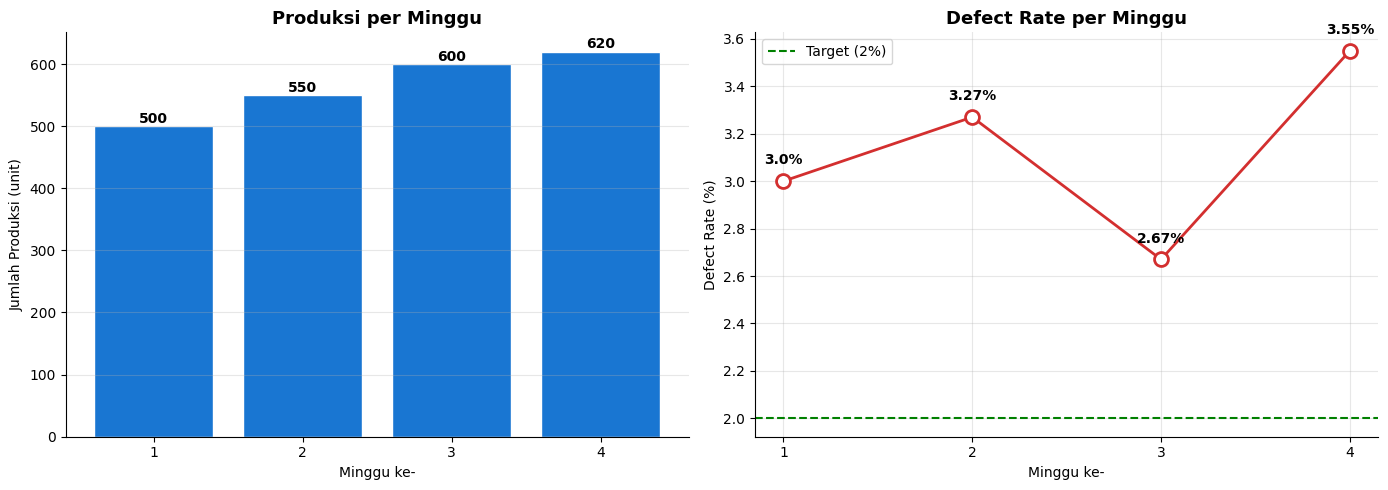

In [8]:
# Visualisasi Produksi vs Defect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Produksi per minggu
colors = ['#43A047' if d < 3 else '#F44336' for d in df['Defect Rate (%)']]
bars = axes[0].bar(df['Minggu'].astype(str), df['Produksi'], color=['#1976D2']*4, edgecolor='white')
axes[0].set_title('Produksi per Minggu', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Minggu ke-')
axes[0].set_ylabel('Jumlah Produksi (unit)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, df['Produksi']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')

# Defect Rate per minggu
axes[1].plot(df['Minggu'].astype(str), df['Defect Rate (%)'],
             marker='o', color='#D32F2F', linewidth=2, markersize=10,
             markerfacecolor='white', markeredgewidth=2)
axes[1].axhline(y=2.0, color='green', linestyle='--', linewidth=1.5, label='Target (2%)')
axes[1].set_title('Defect Rate per Minggu', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Minggu ke-')
axes[1].set_ylabel('Defect Rate (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for i, val in enumerate(df['Defect Rate (%)']):
    axes[1].annotate(f'{val}%', (str(df['Minggu'][i]), val),
                     textcoords="offset points", xytext=(0, 12),
                     ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---

## 6. Forecasting Menggunakan Linear Regression

### 6.1 Pengertian

Forecasting adalah metode untuk memperkirakan nilai masa depan berdasarkan data historis. Pada bagian ini, saya menggunakan **Linear Regression** dari scikit-learn untuk memprediksi produksi bulan ke-7.

### 6.2 Dataset Produksi Bulanan

| Bulan | Produksi |
|-------|----------|
| 1 (Januari) | 1000 |
| 2 (Februari) | 1100 |
| 3 (Maret) | 1200 |
| 4 (April) | 1250 |
| 5 (Mei) | 1350 |
| 6 (Juni) | 1400 |

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Data historis produksi
bulan = [1, 2, 3, 4, 5, 6]
produksi = [1000, 1100, 1200, 1250, 1350, 1400]
nama_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun']

df = pd.DataFrame({
    'Bulan': bulan,
    'Nama Bulan': nama_bulan,
    'Produksi': produksi
})

print("Data Historis Produksi:")
print(df.to_string(index=False))

Data Historis Produksi:
 Bulan Nama Bulan  Produksi
     1        Jan      1000
     2        Feb      1100
     3        Mar      1200
     4        Apr      1250
     5        Mei      1350
     6        Jun      1400


In [10]:
# Membuat model Linear Regression
X = df[['Bulan']]
y = df['Produksi']

model = LinearRegression()
model.fit(X, y)

# Prediksi bulan ke-7, 8, 9
bulan_prediksi = [[7], [8], [9]]
prediksi = model.predict(bulan_prediksi)

print("=" * 50)
print("     HASIL FORECASTING PRODUKSI")
print("=" * 50)
print(f"Koefisien (slope)  : {model.coef_[0]:.2f} unit/bulan")
print(f"Intercept          : {model.intercept_:.2f}")
print(f"R² Score           : {model.score(X, y):.4f}")
print()
print("Prediksi:")
nama_bulan_pred = ['Jul', 'Agu', 'Sep']
for i, pred in enumerate(prediksi):
    print(f"  Bulan ke-{bulan_prediksi[i][0]} ({nama_bulan_pred[i]}) : {pred:.0f} unit")
print("=" * 50)

     HASIL FORECASTING PRODUKSI
Koefisien (slope)  : 80.00 unit/bulan
Intercept          : 936.67
R² Score           : 0.9882

Prediksi:
  Bulan ke-7 (Jul) : 1497 unit
  Bulan ke-8 (Agu) : 1577 unit
  Bulan ke-9 (Sep) : 1657 unit


c:\Users\guest 1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


c:\Users\guest 1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


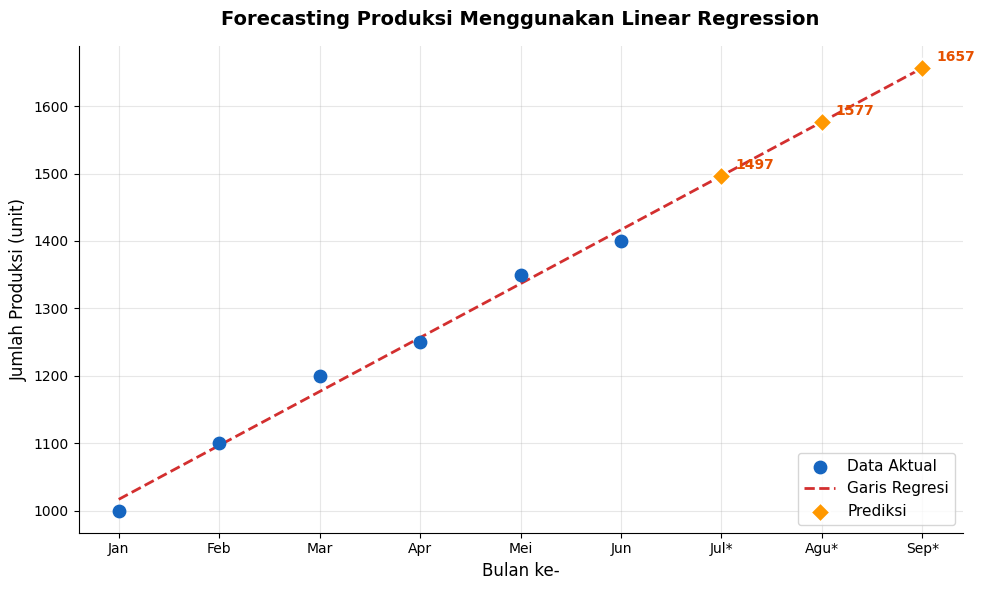

Keterangan: * = Prediksi


In [11]:
# Visualisasi Forecasting
fig, ax = plt.subplots(figsize=(10, 6))

# Data aktual
ax.scatter(bulan, produksi, color='#1565C0', s=80, zorder=5, label='Data Aktual')

# Garis regresi
bulan_extended = np.arange(1, 10).reshape(-1, 1)
pred_extended = model.predict(bulan_extended)
ax.plot(bulan_extended, pred_extended, color='#D32F2F', linewidth=2,
        linestyle='--', label='Garis Regresi')

# Titik prediksi
ax.scatter([7, 8, 9], prediksi, color='#FF9800', s=100, zorder=5,
           marker='D', label='Prediksi', edgecolor='white', linewidth=1.5)

# Label titik prediksi
for i, pred in enumerate(prediksi):
    ax.annotate(f'{pred:.0f}', (bulan_prediksi[i][0], pred),
                textcoords="offset points", xytext=(10, 5),
                fontweight='bold', color='#E65100')

ax.set_title('Forecasting Produksi Menggunakan Linear Regression',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bulan ke-', fontsize=12)
ax.set_ylabel('Jumlah Produksi (unit)', fontsize=12)
ax.set_xticks(range(1, 10))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul*', 'Agu*', 'Sep*'])
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("Keterangan: * = Prediksi")

---

## 7. Mini Project: Dashboard Komprehensif Pabrik Manufaktur

Pada bagian ini, saya mengintegrasikan semua konsep yang sudah dipelajari ke dalam satu analisis yang utuh — mencakup produktivitas, efisiensi, kualitas, dan forecasting.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Data produksi harian (7 hari)
data = {
    'Hari': ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu'],
    'Produksi': [480, 510, 530, 490, 560, 540, 500],
    'Jam Kerja': [8, 8, 8, 8, 8, 7, 6],
    'Tenaga Kerja': [10, 10, 12, 10, 12, 10, 8],
    'Defect': [12, 15, 10, 18, 8, 14, 16],
    'Target': [500, 500, 550, 500, 550, 500, 450],
    'Downtime (menit)': [30, 15, 20, 45, 10, 25, 35],
    'Energi (kWh)': [120, 115, 130, 125, 135, 120, 100]
}

df = pd.DataFrame(data)

# Perhitungan metrik
df['Produktivitas/Jam'] = (df['Produksi'] / df['Jam Kerja']).round(1)
df['Produktivitas/TK'] = (df['Produksi'] / df['Tenaga Kerja']).round(1)
df['Efisiensi (%)'] = ((df['Produksi'] / df['Target']) * 100).round(1)
df['Defect Rate (%)'] = ((df['Defect'] / df['Produksi']) * 100).round(2)
df['Energi/Unit'] = (df['Energi (kWh)'] / df['Produksi']).round(3)

print("=" * 100)
print("                     LAPORAN ANALISIS PRODUKSI — MINI PROJECT")
print("=" * 100)
print(df[['Hari', 'Produksi', 'Target', 'Efisiensi (%)', 'Defect', 'Defect Rate (%)', 
          'Produktivitas/Jam', 'Produktivitas/TK']].to_string(index=False))
print()

# Ringkasan
print("=" * 60)
print("              RINGKASAN KINERJA")
print("=" * 60)
print(f"Total Produksi          : {df['Produksi'].sum():,} unit")
print(f"Total Defect            : {df['Defect'].sum()} unit")
print(f"Overall Defect Rate     : {(df['Defect'].sum() / df['Produksi'].sum() * 100):.2f}%")
print(f"Rata-rata Efisiensi     : {df['Efisiensi (%)'].mean():.1f}%")
print(f"Rata-rata Produktivitas : {df['Produktivitas/Jam'].mean():.1f} unit/jam")
print(f"Total Downtime          : {df['Downtime (menit)'].sum()} menit")
print(f"Total Energi            : {df['Energi (kWh)'].sum()} kWh")
print("=" * 60)

                     LAPORAN ANALISIS PRODUKSI — MINI PROJECT
  Hari  Produksi  Target  Efisiensi (%)  Defect  Defect Rate (%)  Produktivitas/Jam  Produktivitas/TK
 Senin       480     500           96.0      12             2.50               60.0              48.0
Selasa       510     500          102.0      15             2.94               63.8              51.0
  Rabu       530     550           96.4      10             1.89               66.2              44.2
 Kamis       490     500           98.0      18             3.67               61.2              49.0
 Jumat       560     550          101.8       8             1.43               70.0              46.7
 Sabtu       540     500          108.0      14             2.59               77.1              54.0
Minggu       500     450          111.1      16             3.20               83.3              62.5

              RINGKASAN KINERJA
Total Produksi          : 3,610 unit
Total Defect            : 93 unit
Overall Defect Rat

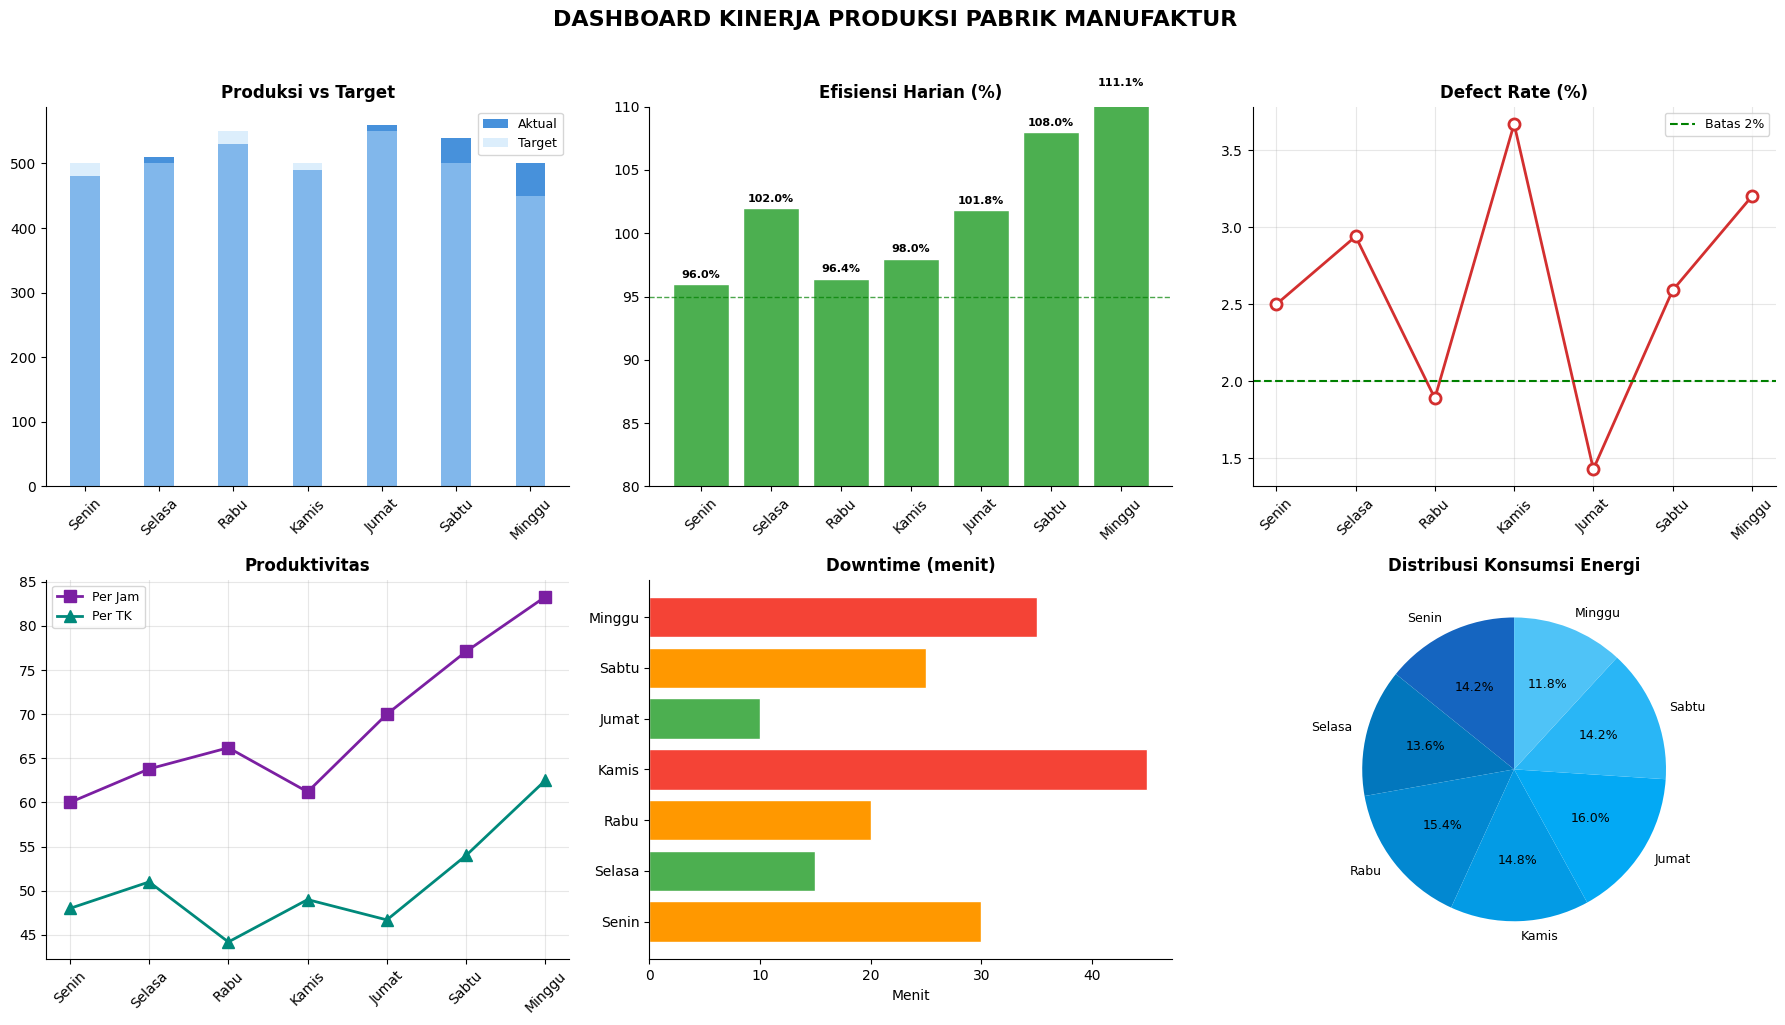

Keterangan Warna Efisiensi: Hijau ≥ 95% | Kuning ≥ 85% | Merah < 85%
Keterangan Warna Downtime: Hijau ≤ 15m | Kuning ≤ 30m | Merah > 30m


In [13]:
# Dashboard Visualisasi Komprehensif
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DASHBOARD KINERJA PRODUKSI PABRIK MANUFAKTUR',
             fontsize=16, fontweight='bold', y=1.02)

# 1. Produksi vs Target
axes[0, 0].bar(df['Hari'], df['Produksi'], color='#1976D2', alpha=0.8, label='Aktual', width=0.4)
axes[0, 0].bar(df['Hari'], df['Target'], color='#BBDEFB', alpha=0.5, label='Target', width=0.4)
axes[0, 0].set_title('Produksi vs Target', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend(fontsize=9)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# 2. Efisiensi
colors_eff = ['#4CAF50' if v >= 95 else '#FF9800' if v >= 85 else '#F44336' for v in df['Efisiensi (%)']]
bars_eff = axes[0, 1].bar(df['Hari'], df['Efisiensi (%)'], color=colors_eff, edgecolor='white')
axes[0, 1].axhline(y=95, color='green', linestyle='--', linewidth=1, alpha=0.7)
axes[0, 1].set_title('Efisiensi Harian (%)', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylim(80, 110)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)
for bar, val in zip(bars_eff, df['Efisiensi (%)']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val}%', ha='center', fontsize=8, fontweight='bold')

# 3. Defect Rate
axes[0, 2].plot(df['Hari'], df['Defect Rate (%)'], marker='o', color='#D32F2F',
                linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0, 2].axhline(y=2.0, color='green', linestyle='--', linewidth=1.5, label='Batas 2%')
axes[0, 2].set_title('Defect Rate (%)', fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].spines['top'].set_visible(False)
axes[0, 2].spines['right'].set_visible(False)

# 4. Produktivitas
axes[1, 0].plot(df['Hari'], df['Produktivitas/Jam'], marker='s', color='#7B1FA2',
                linewidth=2, markersize=8, label='Per Jam')
axes[1, 0].plot(df['Hari'], df['Produktivitas/TK'], marker='^', color='#00897B',
                linewidth=2, markersize=8, label='Per TK')
axes[1, 0].set_title('Produktivitas', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# 5. Downtime
colors_dt = ['#F44336' if v > 30 else '#FF9800' if v > 15 else '#4CAF50' for v in df['Downtime (menit)']]
bars_dt = axes[1, 1].barh(df['Hari'], df['Downtime (menit)'], color=colors_dt, edgecolor='white')
axes[1, 1].set_title('Downtime (menit)', fontweight='bold')
axes[1, 1].set_xlabel('Menit')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

# 6. Pie Chart Distribusi Energi
axes[1, 2].pie(df['Energi (kWh)'], labels=df['Hari'], autopct='%1.1f%%',
               colors=['#1565C0', '#0277BD', '#0288D1', '#039BE5', '#03A9F4', '#29B6F6', '#4FC3F7'],
               startangle=90, textprops={'fontsize': 9})
axes[1, 2].set_title('Distribusi Konsumsi Energi', fontweight='bold')

plt.tight_layout()
plt.show()

print("Keterangan Warna Efisiensi: Hijau ≥ 95% | Kuning ≥ 85% | Merah < 85%")
print("Keterangan Warna Downtime: Hijau ≤ 15m | Kuning ≤ 30m | Merah > 30m")

     FORECASTING PRODUKSI MINGGU DEPAN
R² Score: 0.1616
Tren per hari: +5.4 unit/hari

     Senin (Hari ke-8) : 537 unit
    Selasa (Hari ke-9) : 542 unit
      Rabu (Hari ke-10) : 548 unit


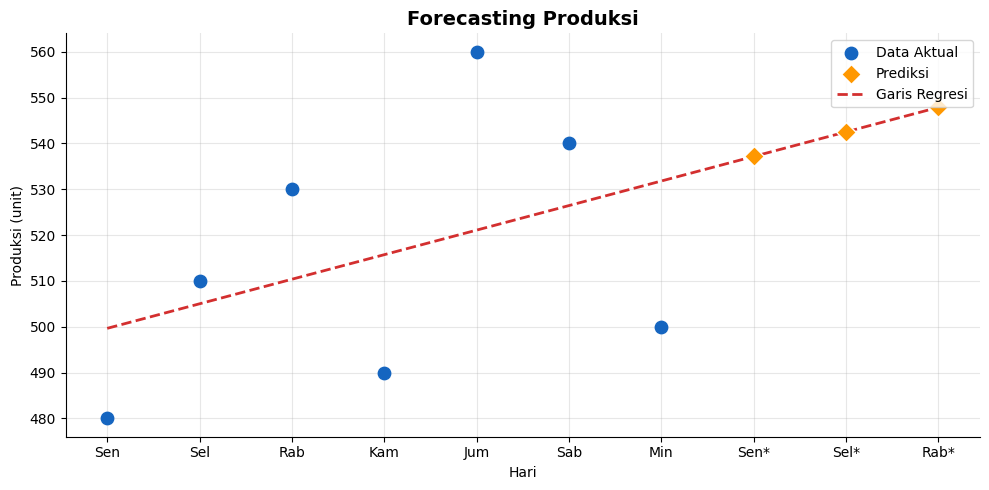

* = Prediksi


In [14]:
# Forecasting produksi minggu depan
from sklearn.linear_model import LinearRegression
import numpy as np

# Siapkan data untuk regresi
X = np.arange(1, 8).reshape(-1, 1)
y = df['Produksi'].values

model = LinearRegression()
model.fit(X, y)

# Prediksi 3 hari ke depan
prediksi_hari = np.array([[8], [9], [10]])
prediksi_produksi = model.predict(prediksi_hari)

print("=" * 50)
print("     FORECASTING PRODUKSI MINGGU DEPAN")
print("=" * 50)
print(f"R² Score: {model.score(X, y):.4f}")
print(f"Tren per hari: +{model.coef_[0]:.1f} unit/hari")
print()
hari_pred = ['Senin', 'Selasa', 'Rabu']
for i, pred in enumerate(prediksi_produksi):
    print(f"  {hari_pred[i]:>8} (Hari ke-{prediksi_hari[i][0]}) : {pred:.0f} unit")
print("=" * 50)

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(range(1, 8), y, color='#1565C0', s=80, zorder=5, label='Data Aktual')
ax.scatter([8, 9, 10], prediksi_produksi, color='#FF9800', s=100, marker='D',
           zorder=5, label='Prediksi', edgecolor='white')

x_line = np.arange(1, 11).reshape(-1, 1)
ax.plot(x_line, model.predict(x_line), color='#D32F2F', linestyle='--', linewidth=2, label='Garis Regresi')

all_labels = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min', 'Sen*', 'Sel*', 'Rab*']
ax.set_xticks(range(1, 11))
ax.set_xticklabels(all_labels)
ax.set_title('Forecasting Produksi', fontsize=14, fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Produksi (unit)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print("* = Prediksi")

## 8. Kesimpulan

Dari seluruh analisis yang saya lakukan dalam notebook ini, berikut kesimpulan utamanya:

1. **Produktivitas** — Pengukuran produktivitas baik per jam kerja maupun per tenaga kerja memberikan gambaran yang jelas tentang efektivitas operasional. Lini produksi yang berbeda bisa memiliki produktivitas yang sangat bervariasi.

2. **Efisiensi** — Dari data yang dianalisis, rata-rata efisiensi masih di bawah target 95%. Departemen Packaging menunjukkan efisiensi tertinggi, sementara Produksi perlu perbaikan.

3. **Defect Rate** — Overall defect rate sebesar 3.13% masih di atas target 2%. Perlu dilakukan root cause analysis menggunakan metode seperti diagram Pareto atau Fishbone.

4. **KPI Dashboard** — Dengan membuat dashboard KPI, manajemen bisa memonitor kinerja secara real-time dan mengambil tindakan korektif lebih cepat.

5. **Forecasting** — Model linear regression memberikan prediksi yang cukup baik untuk tren produksi. Namun, untuk data yang lebih kompleks, model yang lebih advanced (seperti polynomial regression atau time series) mungkin diperlukan.

Secara keseluruhan, Python dengan ekosistem library-nya (Pandas, Matplotlib, Scikit-learn) merupakan alat yang sangat efektif untuk melakukan analisis data industri secara menyeluruh — mulai dari pengolahan data hingga prediksi.